# 03d — Diagnostic 3: does training scope explain the gap? (transferability)

Our step-2 model (Colombia only) predicts far less regrowth than the authors'
pantropical map in the same domain. This notebook trains **the same model
specification** (`make_rf` of `03_analysis`, ten predictors, 39,523 balanced
records) on the Neotropical sample of `02c_neotropics_sample` and tests transfer.

**Test 1 — Colombia held out.** Models trained (i) on Neotropical points
outside Colombia and (ii) on all Neotropical points, are compared with our
Colombia model (refitted exactly as in `03`) and the authors' map:
accuracy on our Colombian validation set (2000 inputs); mean score and share of
p > 0.5 on Colombian non-regrowth validation points with 2000 and with 2018
inputs; uncalibrated expected area and p > 0.5 area on the 1-in-100 systematic
grid (2018 inputs, exact WGS84 pixel areas, as in `03`); Pearson correlation with
the authors' map per pixel and at HEALPix depth 8.

**Test 2 — transferability curve.** 5-fold cross-validation on the Neotropical
training pool: random folds, and folds grouped by HEALPix cell (NESTED, WGS84)
at depths 6, 5 and 4 (~100, ~200, ~400 km).

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from healpix_geo.nested import lonlat_to_healpix
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupKFold, StratifiedKFold

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
SMOKE = os.environ.get("SMOKE", "0") == "1"
CLEAN = Path("../data/clean_smoke" if SMOKE else "../data/clean")
RESULTS = Path("../results/smoke" if SMOKE else "../results")
FIGURES = Path("../figures/smoke" if SMOKE else "../figures")
for d in (RESULTS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)
N_TREES = 100 if SMOKE else 500
SEED = 20261003
MHA = 1e10
GRID_W = 100
FINAL_VARS = ["forest_density_2000", "dist_forest_2000", "ocdens", "phihox", "pc1", "pc2", "pc3", "pc4", "lc_2000", "biome"]
PRED_MAP = {"forest_density_2000": "forest_density_2018", "dist_forest_2000": "dist_forest_2018", "lc_2000": "lc_2015"}
VARS_2018 = [PRED_MAP.get(v, v) for v in FINAL_VARS]
COL_SHARE = 188_921 / 4_780_000
N_TRAIN = 2_000 if SMOKE else int(round(1_000_000 * COL_SHARE))

samples = pd.read_parquet(CLEAN / "samples.parquet")
grid = pd.read_parquet(CLEAN / "pred_grid.parquet")
neo = pd.read_parquet(CLEAN / "neotropics_samples.parquet")
sums = pd.read_csv(CLEAN / "tile_sums.csv").drop(columns="tile").sum()
print(neo.groupby(["set", "in_colombia", "label"]).size().to_string())


def make_rf(max_features: int = 3, seed: int = SEED) -> RandomForestClassifier:
    """Identical to 03_analysis.make_rf (R randomForest classification defaults)."""
    return RandomForestClassifier(n_estimators=N_TREES, max_features=max_features, min_samples_leaf=1, bootstrap=True,
                                  oob_score=True, n_jobs=-1, random_state=seed)


def balanced_train(pool: pd.DataFrame, n: int = N_TRAIN, seed: int = SEED) -> pd.DataFrame:
    return pd.concat([g.sample(n=min(n // 2, len(g)), random_state=seed) for _, g in pool.groupby("label")])

set         in_colombia  label
train_pool  False        0        23760
                         1        24415
            True         0         2265
                         1         1610
validation  False        0         7938
                         1         8105
            True         0          737
                         1          570


## Training sets

The Colombia model uses exactly the step-2 draw of `03`. The two Neotropical
models draw the same number of balanced records from the Neotropical training
pool, with and without its Colombian points. Neotropical points that coincide
with a Colombian validation pixel are removed from training.

In [3]:
col_pool = samples[samples.set == "train_pool"]
col_val = samples[samples.set == "validation"].reset_index(drop=True)
val_key = set(zip(col_val.grow, col_val.gcol))
neo_pool = neo[(neo.set == "train_pool") & ~pd.Series(list(zip(neo.grow, neo.gcol)), index=neo.index).isin(val_key)]
neo_val_out = neo[(neo.set == "validation") & ~neo.in_colombia]
TRAIN = {
    "colombia": pd.concat([g.sample(n=min(N_TRAIN // 2, len(g)), random_state=SEED) for _, g in col_pool.groupby("label")]),
    "neotropics_excl_colombia": balanced_train(neo_pool[~neo_pool.in_colombia]),
    "neotropics_incl_colombia": balanced_train(neo_pool),
}
for k, t in TRAIN.items():
    col_pts = int(t.in_colombia.sum()) if "in_colombia" in t else len(t)
    print(f"{k:26s} n={len(t):,} {t.label.value_counts().to_dict()} Colombian points {col_pts:,}")
MODELS = {k: make_rf().fit(t[FINAL_VARS].to_numpy(), t.label.to_numpy()) for k, t in TRAIN.items()}

colombia                   n=39,522 {0: 19761, 1: 19761} Colombian points 39,522
neotropics_excl_colombia   n=39,522 {0: 19761, 1: 19761} Colombian points 0
neotropics_incl_colombia   n=39,522 {0: 19761, 1: 19761} Colombian points 2,882


## Test 1: transfer to Colombia

In [4]:
A = 6378137.0


def sphere_over_ellipsoid(lat: np.ndarray) -> np.ndarray:
    res = 0.00025
    f = 1 / 298.257223563
    e2 = f * (2 - f)
    e = np.sqrt(e2)
    q = lambda phi: (1 - e2) * (np.sin(phi) / (1 - e2 * np.sin(phi) ** 2)  # noqa: E731
                                - np.log((1 - e * np.sin(phi)) / (1 + e * np.sin(phi))) / (2 * e))
    top, bot = np.radians(lat + res / 2), np.radians(lat - res / 2)
    return (A**2 * (np.sin(top) - np.sin(bot))) / (A**2 / 2 * (q(top) - q(bot)))


def area_estimates(df: pd.DataFrame, weight: np.ndarray) -> dict[str, float]:
    """As in 03_analysis: 1-in-100 systematic grid, exact WGS84 pixel area x 100."""
    a_ell = df.area_ell.to_numpy() * GRID_W
    y = weight * a_ell
    n = len(y)
    se = np.sqrt(n * y.var(ddof=1) * (1 - 1 / GRID_W)) if n > 1 else np.nan
    return {"ell": y.sum() / MHA, "ell_se": se / MHA,
            "sph": (y * sphere_over_ellipsoid(df.lat.to_numpy())).sum() / MHA,
            "nom": (weight * 900.0 * GRID_W).sum() / MHA}


g = grid[grid.is_pred_domain].copy()
Xg = g[VARS_2018].to_numpy()
ok = ~np.isnan(Xg).any(axis=1)
g, Xg = g[ok].copy(), Xg[ok]
g["cell8"] = lonlat_to_healpix(g.lon.to_numpy(), g.lat.to_numpy(), 8, ellipsoid="WGS84")
grid["cell8"] = lonlat_to_healpix(grid.lon.to_numpy(), grid.lat.to_numpy(), 8, ellipsoid="WGS84")
cell_dom = (grid.area_ell * GRID_W).groupby(grid.cell8).sum()
big = cell_dom[cell_dom > 0.5 * cell_dom.max()].index
if SMOKE and len(big) < 3:
    big = cell_dom.index
auth_ok = (g.auth_pct <= 100).to_numpy()
auth_p = np.where(auth_ok, g.auth_pct.to_numpy(), 0) / 100
print(f"grid points in the prediction domain with complete predictors: {len(g):,}; HEALPix d8 cells used: {len(big)}")


def healpix_r(p: np.ndarray) -> float:
    w = g.area_ell.to_numpy() * GRID_W
    c = pd.DataFrame({"cell": g.cell8.to_numpy(), "ours": p * w, "auth": auth_p * w}).groupby("cell").sum()
    c = c.reindex(big).fillna(0.0).div(cell_dom.reindex(big), axis=0)
    return float(stats.pearsonr(c.ours, c.auth)[0])


nr = col_val[col_val.label == 0]
rows, scores = [], {}
for name, m in MODELS.items():
    p_val = m.predict_proba(col_val[FINAL_VARS].to_numpy())[:, 1]
    p_nr00 = m.predict_proba(nr[FINAL_VARS].to_numpy())[:, 1]
    p_nr18 = m.predict_proba(nr[VARS_2018].to_numpy())[:, 1]
    p_grid = m.predict_proba(Xg)[:, 1]
    scores[name] = p_nr18
    exp_a, bin_a = area_estimates(g, p_grid), area_estimates(g, (p_grid > 0.5).astype(float))
    neo_acc = np.nan
    if name != "colombia" and len(neo_val_out):
        neo_acc = float(((m.predict_proba(neo_val_out[FINAL_VARS].to_numpy())[:, 1] > 0.5) == neo_val_out.label).mean())
    rows.append(dict(
        model=name, n_train=len(TRAIN[name]),
        n_train_colombian=int(TRAIN[name].in_colombia.sum()) if "in_colombia" in TRAIN[name] else len(TRAIN[name]),
        oob_accuracy=float(m.oob_score_), colombia_val_accuracy=float(((p_val > 0.5) == col_val.label).mean()),
        colombia_val_n=len(col_val), neotropics_val_accuracy_excl_colombia=neo_acc,
        nonregrowth_mean_p_2000=float(p_nr00.mean()), nonregrowth_share_gt05_2000=float((p_nr00 > 0.5).mean()),
        nonregrowth_mean_p_2018=float(p_nr18.mean()), nonregrowth_share_gt05_2018=float((p_nr18 > 0.5).mean()),
        nonregrowth_n=len(nr), regrowth_mean_p_2000=float(p_val[col_val.label == 1].mean()),
        expected_area_uncal_mha=exp_a["ell"], expected_area_se_mha=exp_a["ell_se"],
        expected_area_mollweide_sphere_mha=exp_a["sph"], area_p_gt05_mha=bin_a["ell"],
        area_p_gt05_se_mha=bin_a["ell_se"],
        pixel_pearson_vs_authors_pct=float(stats.pearsonr(p_grid[auth_ok], auth_p[auth_ok])[0]),
        healpix_d8_pearson_vs_authors=healpix_r(p_grid),
        note="refit of the step-2 model (same draw and seed as 03)" if name == "colombia" else
             "Neotropical sample (02c); same specification as step 2"))
    print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in rows[-1].items()})

va = col_val.auth_pct <= 100
nra = nr[nr.auth_pct <= 100]
scores["authors_map"] = nra.auth_pct.to_numpy() / 100
exp_auth = area_estimates(g, auth_p)
bin_auth = area_estimates(g, (auth_p > 0.5).astype(float))
rows.append(dict(
    model="authors_map", colombia_val_accuracy=float(((col_val.auth_pct[va] > 50) == col_val.label[va]).mean()),
    colombia_val_n=int(va.sum()),
    nonregrowth_mean_p_2018=float(nra.auth_pct.mean() / 100), nonregrowth_share_gt05_2018=float((nra.auth_pct > 50).mean()),
    nonregrowth_n=len(nra), regrowth_mean_p_2000=float(col_val.auth_pct[va & (col_val.label == 1)].mean() / 100),
    expected_area_uncal_mha=exp_auth["ell"], expected_area_se_mha=exp_auth["ell_se"],
    expected_area_mollweide_sphere_mha=exp_auth["sph"], area_p_gt05_mha=bin_auth["ell"], area_p_gt05_se_mha=bin_auth["ell_se"],
    pixel_pearson_vs_authors_pct=1.0, healpix_d8_pearson_vs_authors=1.0,
    note=("authors' published continuous map (Zenodo 7428804), pct/100 at the same pixels; NoData (pct > 100) counted 0 "
          f"in areas and excluded from point metrics; exact 30 m expected area in our prediction domain = "
          f"{sums['auth_expected_pred_ell'] / MHA:.3f} Mha; 2018 columns = the map itself")))
t1 = pd.DataFrame(rows)
t1.to_csv(RESULTS / "diag3_transfer_colombia.csv", index=False)
with pd.option_context("display.width", 250, "display.max_columns", 40):
    print(t1.drop(columns="note").T.to_string(float_format=lambda v: f"{v:.4f}"))

grid points in the prediction domain with complete predictors: 2,456,636; HEALPix d8 cells used: 1451


{'model': 'colombia', 'n_train': 39522, 'n_train_colombian': 39522, 'oob_accuracy': 0.8844, 'colombia_val_accuracy': 0.8867, 'colombia_val_n': 123356, 'neotropics_val_accuracy_excl_colombia': nan, 'nonregrowth_mean_p_2000': 0.1865, 'nonregrowth_share_gt05_2000': 0.0796, 'nonregrowth_mean_p_2018': 0.1675, 'nonregrowth_share_gt05_2018': 0.0578, 'nonregrowth_n': 61678, 'regrowth_mean_p_2000': 0.8271, 'expected_area_uncal_mha': np.float64(3.9887), 'expected_area_se_mha': np.float64(0.0025), 'expected_area_mollweide_sphere_mha': np.float64(4.015), 'area_p_gt05_mha': np.float64(2.0259), 'area_p_gt05_se_mha': np.float64(0.0037), 'pixel_pearson_vs_authors_pct': 0.6782, 'healpix_d8_pearson_vs_authors': 0.86, 'note': 'refit of the step-2 model (same draw and seed as 03)'}


{'model': 'neotropics_excl_colombia', 'n_train': 39522, 'n_train_colombian': 0, 'oob_accuracy': 0.8978, 'colombia_val_accuracy': 0.7671, 'colombia_val_n': 123356, 'neotropics_val_accuracy_excl_colombia': 0.9005, 'nonregrowth_mean_p_2000': 0.2286, 'nonregrowth_share_gt05_2000': 0.0448, 'nonregrowth_mean_p_2018': 0.2177, 'nonregrowth_share_gt05_2018': 0.0358, 'nonregrowth_n': 61678, 'regrowth_mean_p_2000': 0.6605, 'expected_area_uncal_mha': np.float64(4.4486), 'expected_area_se_mha': np.float64(0.0017), 'expected_area_mollweide_sphere_mha': np.float64(4.4779), 'area_p_gt05_mha': np.float64(0.8762), 'area_p_gt05_se_mha': np.float64(0.0025), 'pixel_pearson_vs_authors_pct': 0.5295, 'healpix_d8_pearson_vs_authors': 0.9112, 'note': 'Neotropical sample (02c); same specification as step 2'}


{'model': 'neotropics_incl_colombia', 'n_train': 39522, 'n_train_colombian': 2882, 'oob_accuracy': 0.8909, 'colombia_val_accuracy': 0.7835, 'colombia_val_n': 123356, 'neotropics_val_accuracy_excl_colombia': 0.8981, 'nonregrowth_mean_p_2000': 0.2455, 'nonregrowth_share_gt05_2000': 0.0761, 'nonregrowth_mean_p_2018': 0.2322, 'nonregrowth_share_gt05_2018': 0.0605, 'nonregrowth_n': 61678, 'regrowth_mean_p_2000': 0.6862, 'expected_area_uncal_mha': np.float64(4.6056), 'expected_area_se_mha': np.float64(0.0019), 'expected_area_mollweide_sphere_mha': np.float64(4.6359), 'area_p_gt05_mha': np.float64(1.3474), 'area_p_gt05_se_mha': np.float64(0.0031), 'pixel_pearson_vs_authors_pct': 0.4632, 'healpix_d8_pearson_vs_authors': 0.8817, 'note': 'Neotropical sample (02c); same specification as step 2'}


                                               0                         1                         2            3
model                                   colombia  neotropics_excl_colombia  neotropics_incl_colombia  authors_map
n_train                               39522.0000                39522.0000                39522.0000          NaN
n_train_colombian                     39522.0000                    0.0000                 2882.0000          NaN
oob_accuracy                              0.8844                    0.8978                    0.8909          NaN
colombia_val_accuracy                     0.8867                    0.7671                    0.7835       0.4869
colombia_val_n                            123356                    123356                    123356        62915
neotropics_val_accuracy_excl_colombia        NaN                    0.9005                    0.8981          NaN
nonregrowth_mean_p_2000                   0.1865                    0.2286              

## Test 2: transferability curve within the Neotropics

In [5]:
pv = neo_pool.reset_index(drop=True)
Xp, yp = pv[FINAL_VARS].to_numpy(), pv.label.to_numpy()
schemes = {"random": (None, 5, StratifiedKFold(5, shuffle=True, random_state=SEED).split(Xp, yp))}
for depth in [6, 5, 4]:
    cells = lonlat_to_healpix(pv.lon.to_numpy(), pv.lat.to_numpy(), depth, ellipsoid="WGS84")
    n_groups = len(np.unique(cells))
    k = min(5, n_groups)  # fewer folds only if there are fewer than 5 cells (smoke test)
    schemes[f"healpix_d{depth}"] = (n_groups, k, GroupKFold(k).split(Xp, yp, groups=cells))
APPROX_KM = {"random": 0, "healpix_d6": 100, "healpix_d5": 200, "healpix_d4": 400}
cv_rows = []
for name, (n_groups, n_folds, splits) in schemes.items():
    accs, baccs, mp0, sh0 = [], [], [], []
    for k, (tri, tei) in enumerate(splits):
        sub = np.random.default_rng(SEED + k).choice(tri, min(N_TRAIN, len(tri)), replace=False)
        m = make_rf().fit(Xp[sub], yp[sub])
        p = m.predict_proba(Xp[tei])[:, 1]
        accs.append(float(((p > 0.5) == yp[tei]).mean()))
        baccs.append(float(balanced_accuracy_score(yp[tei], p > 0.5)))
        mp0.append(float(p[yp[tei] == 0].mean()))
        sh0.append(float((p[yp[tei] == 0] > 0.5).mean()))
    cv_rows.append(dict(scheme=name, block_km_approx=APPROX_KM[name], n_groups=n_groups, n_folds=n_folds, n_pool=len(pv),
                        mean_accuracy=np.mean(accs), sd_accuracy=np.std(accs, ddof=1),
                        mean_balanced_accuracy=np.mean(baccs), sd_balanced_accuracy=np.std(baccs, ddof=1),
                        nonregrowth_mean_p=np.mean(mp0), sd_nonregrowth_mean_p=np.std(mp0, ddof=1),
                        nonregrowth_share_gt05=np.mean(sh0), folds_accuracy=" ".join(f"{a:.4f}" for a in accs)))
    print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in cv_rows[-1].items()})
curve = pd.DataFrame(cv_rows)
curve.to_csv(RESULTS / "diag3_transfer_curve.csv", index=False)

{'scheme': 'random', 'block_km_approx': 0, 'n_groups': None, 'n_folds': 5, 'n_pool': 52012, 'mean_accuracy': np.float64(0.8921), 'sd_accuracy': np.float64(0.0023), 'mean_balanced_accuracy': np.float64(0.892), 'sd_balanced_accuracy': np.float64(0.0023), 'nonregrowth_mean_p': np.float64(0.1773), 'sd_nonregrowth_mean_p': np.float64(0.0027), 'nonregrowth_share_gt05': np.float64(0.0746), 'folds_accuracy': '0.8940 0.8939 0.8883 0.8922 0.8919'}


{'scheme': 'healpix_d6', 'block_km_approx': 100, 'n_groups': 187, 'n_folds': 5, 'n_pool': 52012, 'mean_accuracy': np.float64(0.834), 'sd_accuracy': np.float64(0.0193), 'mean_balanced_accuracy': np.float64(0.833), 'sd_balanced_accuracy': np.float64(0.0195), 'nonregrowth_mean_p': np.float64(0.2028), 'sd_nonregrowth_mean_p': np.float64(0.0249), 'nonregrowth_share_gt05': np.float64(0.069), 'folds_accuracy': '0.8254 0.8181 0.8613 0.8468 0.8182'}


{'scheme': 'healpix_d5', 'block_km_approx': 200, 'n_groups': 48, 'n_folds': 5, 'n_pool': 52012, 'mean_accuracy': np.float64(0.8226), 'sd_accuracy': np.float64(0.0296), 'mean_balanced_accuracy': np.float64(0.8217), 'sd_balanced_accuracy': np.float64(0.0315), 'nonregrowth_mean_p': np.float64(0.2324), 'sd_nonregrowth_mean_p': np.float64(0.0266), 'nonregrowth_share_gt05': np.float64(0.067), 'folds_accuracy': '0.7853 0.8076 0.8195 0.8632 0.8374'}


{'scheme': 'healpix_d4', 'block_km_approx': 400, 'n_groups': 40, 'n_folds': 5, 'n_pool': 52012, 'mean_accuracy': np.float64(0.8124), 'sd_accuracy': np.float64(0.0402), 'mean_balanced_accuracy': np.float64(0.8095), 'sd_balanced_accuracy': np.float64(0.0508), 'nonregrowth_mean_p': np.float64(0.2308), 'sd_nonregrowth_mean_p': np.float64(0.0515), 'nonregrowth_share_gt05': np.float64(0.0743), 'folds_accuracy': '0.7928 0.7514 0.8355 0.8505 0.8317'}


## Figure

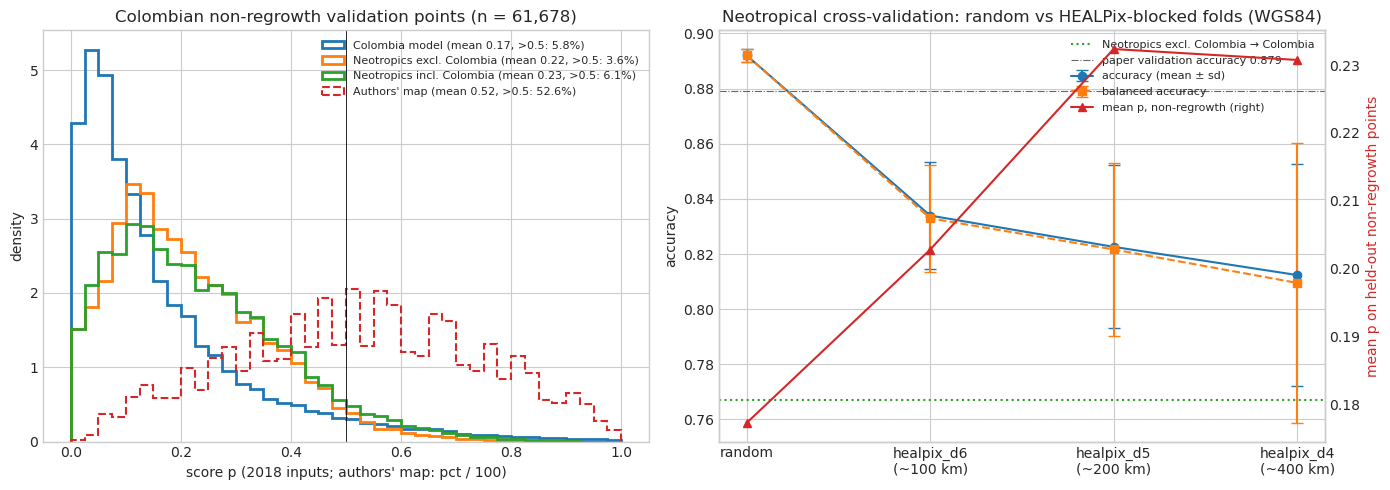

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.linspace(0, 1, 41)
labels = {"colombia": "Colombia model", "neotropics_excl_colombia": "Neotropics excl. Colombia",
          "neotropics_incl_colombia": "Neotropics incl. Colombia", "authors_map": "Authors' map"}
for k, s in scores.items():
    axes[0].hist(s, bins=bins, histtype="step", density=True, lw=2 if k != "authors_map" else 1.5,
                 ls="--" if k == "authors_map" else "-", label=f"{labels[k]} (mean {s.mean():.2f}, >0.5: {(s > 0.5).mean():.1%})")
axes[0].axvline(0.5, color="k", lw=0.6)
axes[0].set_xlabel("score p (2018 inputs; authors' map: pct / 100)")
axes[0].set_ylabel("density")
axes[0].set_title(f"Colombian non-regrowth validation points (n = {len(nr):,})")
axes[0].legend(fontsize=8)
x = np.arange(len(curve))
axes[1].errorbar(x, curve.mean_accuracy, yerr=curve.sd_accuracy, fmt="o-", capsize=4, label="accuracy (mean ± sd)")
axes[1].errorbar(x, curve.mean_balanced_accuracy, yerr=curve.sd_balanced_accuracy, fmt="s--", capsize=4,
                 label="balanced accuracy")
ex = t1.set_index("model")
axes[1].axhline(ex.loc["neotropics_excl_colombia", "colombia_val_accuracy"], color="C2", ls=":",
                label="Neotropics excl. Colombia → Colombia")
axes[1].axhline(0.879, color="0.4", ls="-.", lw=0.8, label="paper validation accuracy 0.879")
axes[1].set_xticks(x, [f"{s}\n(~{k} km)" if k else s for s, k in zip(curve.scheme, curve.block_km_approx)])
axes[1].set_ylabel("accuracy")
ax2 = axes[1].twinx()
ax2.plot(x, curve.nonregrowth_mean_p, "^-", color="C3", label="mean p, non-regrowth (right)")
ax2.set_ylabel("mean p on held-out non-regrowth points", color="C3")
ax2.grid(False)
h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, fontsize=8, loc="best")
axes[1].set_title("Neotropical cross-validation: random vs HEALPix-blocked folds (WGS84)")
fig.tight_layout()
fig.savefig(FIGURES / "diag3_transfer.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
json.dump({"n_train": {k: len(v) for k, v in TRAIN.items()}, "n_neo_pool": len(pv), "n_trees": N_TREES},
          open(RESULTS / ("diag3_meta.json"), "w"), indent=2)